In [1]:
from parameters import load_json
from simulation import run_readout_pair


def test_example_readout_runs():
    device, pulse, simulation = load_json("device_parameter.json")
    result = run_readout_pair(device, pulse, simulation)
    print(result)

    assert result.ground.resonator_population.shape == simulation.tsave.shape
    assert result.excited.resonator_population.shape == simulation.tsave.shape
    assert result.snr.shape == simulation.tsave.shape
    assert result.assignment_error.shape == simulation.tsave.shape
   # assert result.ground.leakage[-1] >= -1e-8
   # assert result.excited.leakage[-1] >= -1e-8

    return device, pulse, simulation, result

In [ ]:
device, pulse, simulation, result = test_example_readout_runs()

/mnt/d/GPU_fluxonium/hamiltonian.py:55: UserWarning: A sparse qarray has been converted to dense layout due to element-wise addition with a dense qarray.
  "h_static": h_resonator + h_fluxonium + params.g * drive_op @ n,


58.927277


2026-07-06 12:13:49.214464: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3023] Can't reduce memory use below 3.90GiB (4183026335 bytes) by rematerialization; only reduced to 13.41GiB (14395097553 bytes), down from 13.41GiB (14395097745 bytes) originally
2026-07-06 12:14:00.845049: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.28GiB (rounded to 4592609024)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2026-07-06 12:14:00.845150: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] ***************************************************************_____________________________________
E0706 12:14:00.845171   77106 pjrt_stream_executor_client.cc:2916] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while tr

XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 4592608800 bytes.

: 

/tmp/ipykernel_1001/3560470246.py:73: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axs[1,1].set_yscale("log")


Figure saved as: readout_results_20260706_082207_Nr65_kappa2.5_qubit_levels22.pdf


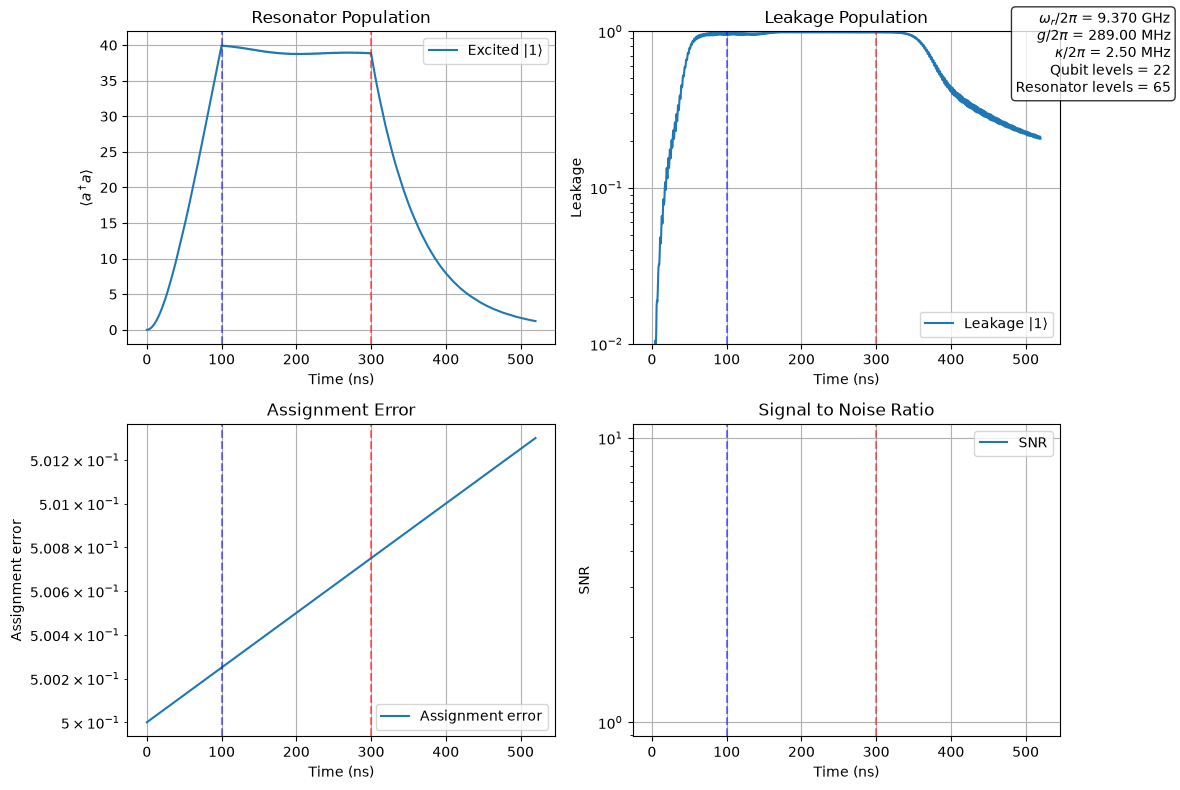

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import json



device, pulse, simulation = load_json("device_parameter.json")
t = np.asarray(simulation.tsave)
n_g = np.asarray(result.ground.resonator_population)
n_e = np.asarray(result.excited.resonator_population)
leak_g = np.asarray(result.ground.leakage)
leak_e = np.asarray(result.excited.leakage)
assignment_error = np.asarray(result.assignment_error)
snr = np.asarray(result.snr)

with open("device_parameter.json", "r") as f:
    params = json.load(f)

# Create text string
textstr = "\n".join([
    rf"$\omega_r/2\pi$ = {params['device']['omega_r']/(2*np.pi):.3f} GHz",
    rf"$g/2\pi$ = {params['device']['g']/(2*np.pi)*1e3:.2f} MHz",
    rf"$\kappa/2\pi$ = {params['device']['kappa']/(2*np.pi)*1e3:.2f} MHz",
    f"Qubit levels = {len(params["device"]["omega_levels"])}",
    f"Resonator levels = {params['device']['resonator_dim']}"
])

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# ---------------- RESONATOR POPULATION ----------------
#axs[0,0].plot(t, n_g, label="Ground |0⟩")
axs[0,0].plot(t, n_e, label="Excited |1⟩")
axs[0,0].axvline(100, color="b", linestyle="--", alpha=0.5)
axs[0,0].axvline(300, color="r", linestyle="--", alpha=0.5)
axs[0,0].set_xlabel("Time (ns)")
axs[0,0].set_ylabel(r"$\langle a^\dagger a\rangle$")
axs[0,0].set_title("Resonator Population")
axs[0,0].grid(True)
#axs[0,0].set_yscale("log")
axs[0,0].legend()

# ---------------- LEAKAGE POPULATION ----------------
#axs[0,1].plot(t, leak_g, label="Leakage |0⟩")
axs[0,1].plot(t, leak_e, label="Leakage |1⟩")
axs[0,1].axvline(100, color="b", linestyle="--", alpha=0.5)
axs[0,1].axvline(300, color="r", linestyle="--", alpha=0.5)
axs[0,1].set_xlabel("Time (ns)")
axs[0,1].set_ylabel("Leakage")
axs[0,1].set_title("Leakage Population")
axs[0,1].set_yscale("log")
axs[0,1].set_ybound(1e-2, 1e0)
axs[0,1].grid(True)
axs[0,1].legend()

# ---------------- ASSIGNMENT ERROR ----------------
axs[1,0].plot(t, assignment_error, label="Assignment error")
axs[1,0].axvline(100, color="b", linestyle="--", alpha=0.5)
axs[1,0].axvline(300, color="r", linestyle="--", alpha=0.5)
axs[1,0].set_xlabel("Time (ns)")
axs[1,0].set_ylabel("Assignment error")
axs[1,0].set_title("Assignment Error")
axs[1,0].set_yscale("log")
axs[1,0].grid(True)
axs[1,0].legend()

# ---------------- SNR PLOT ----------------
axs[1,1].plot(t, snr, label="SNR")
axs[1,1].axvline(100, color="b", linestyle="--", alpha=0.5)
axs[1,1].axvline(300, color="r", linestyle="--", alpha=0.5)
axs[1,1].set_xlabel("Time (ns)")
axs[1,1].set_ylabel("SNR")
axs[1,1].set_title("Signal to Noise Ratio")
axs[1,1].set_yscale("log")
axs[1,1].grid(True)
axs[1,1].legend()

# Put parameter box once on the figure
fig.text(
    0.98, 0.98, textstr,
    ha='right', va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout(rect=[0, 0, 0.9, 1])
qubit_levels = len(params["device"]["omega_levels"])
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
res_dim = params['device']['resonator_dim']
kappa = params["device"]["kappa"]/ (2* np.pi) * 1e3
filename = f"readout_results_{timestamp}_Nr{res_dim}_kappa{kappa}_qubit_levels{qubit_levels}.pdf"
#np.savez(f"Kappa_is_{kappa},Resonator_Population_{res_dim}, Qubit_levels_{qubit_levels}", t= t, n_g = n_g, n_e = n_e, leak_g = leak_g, leak_e = leak_e, assignment_error = assignment_error, snr =snr)
fig.savefig(filename, bbox_inches='tight')
print(f"Figure saved as: {filename}") 
plt.show()

In [4]:
np.load("Kappa_is_10.0,Resonator_Population_65, Qubit_levels_20.npz")

NpzFile 'Kappa_is_10.0,Resonator_Population_65, Qubit_levels_20.npz' with keys: t, n_g, n_e, leak_g, leak_e...

In [5]:
import dynamiqs as dq
from parameters import DeviceParameters, PulseParameters
from hamiltonian import basis_state
def population_in_each_qubit_state(params:DeviceParameters, pulse: PulseParameters):
    population = {}

    for i in range(params.fluxonium_dim):
        for n in range(params.resonator_dim):

            psi = basis_state(params, i, n)
            P = psi @ psi.dag()

            population[(i, n)] = dq.expect(P, result.)

    return population


SyntaxError: invalid syntax (3713959231.py, line 13)

In [ ]:
population_in_each_qubit_state(device, pulse)

AttributeError: 'ReadoutPairResult' object has no attribute 'states'

In [ ]:
x = np.array([[0.0000000e+00, 3.8219834e-05, 1.5371927e-05, 3.5963397e-04,
        3.5881426e-04, 3.5869735e-04],
       [1.0000000e+00, 9.9982578e-01, 9.9957067e-01,  1.0000000e+00,
        1.0000000e+00, 1.0000000e+00],
       [0.0000000e+00, 1.0869500e-04, 3.6062443e-04,  0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]])

In [ ]:
print(x[2:,: ])

[[0.0 0.000108695 0.00036062443 Ellipsis 0.0 0.0 0.0]]
